# Stanford 2D-3D-S dataset

The [Stanford 2D-3D-Semantics](https://buildingparser.stanford.edu/dataset.html)
dataset provides panoramic RGB images of indoor scenes together with
per-pixel semantic labels and depth maps. Because each panorama covers a full
360° field of view, the images live naturally on the 2-sphere — making them
an ideal benchmark for spherical neural networks.

This notebook shows how to:

1. **Download and prepare** the dataset using `Stanford2D3DSDownloader`
2. **Visualize** RGB inputs, semantic segmentation labels, and depth maps
3. **Inspect** the class distribution and depth statistics

## Setup

In [1]:
import os
import numpy as np
import h5py as h5

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from torch_harmonics.plotting import imshow_sphere, plot_sphere

from torch_harmonics.examples import Stanford2D3DSDownloader

/home/thorsten/.conda/envs/torch_harmonics/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Download and prepare the dataset

The `Stanford2D3DSDownloader` handles downloading, extracting, and converting
the raw panoramas into an HDF5 file. If the file already exists the download
is skipped:

In [2]:
data_dir = "../examples/data/2D3DS"
os.makedirs(data_dir, exist_ok=True)

# 2D3DS download & dataset initialization
downloader = Stanford2D3DSDownloader(base_url="https://cvg-data.inf.ethz.ch/2d3ds/no_xyz/", local_dir=str(data_dir))
dataset_file = downloader.prepare_dataset([("area_1_no_xyz.tar", "area_1")], "stanford_2d3ds_dataset_ds16.h5")

Dataset file at ../examples/data/2D3DS/stanford_2d3ds_dataset_ds16.h5 already exists. Skipping download and conversion. If you want to create a new dataset file, delete or rename the existing file.


## Loading the dataset

The HDF5 file contains the RGB images, semantic labels, depth maps, and
associated metadata (class labels, normalization statistics). We load a
single sample to inspect:

In [3]:
h5file = h5.File(dataset_file, "r")

inp = np.transpose(h5file["rgb"][0, ...], (1,2,0))
tar = h5file["semantic"][0, ...]
dep = h5file["depth"][0, ...]
class_labels = h5file["class_labels"]
class_histogram = h5file["class_histogram"]
num_classes = len(class_labels)

## Semantic segmentation

Each pixel is assigned one of 14 semantic classes (wall, floor, ceiling,
furniture, etc.). Let us visualize a few samples side-by-side with their
RGB inputs. The class labels stored in the dataset are:

In [4]:
class_labels

<HDF5 dataset "class_labels": shape (14,), type "|O">

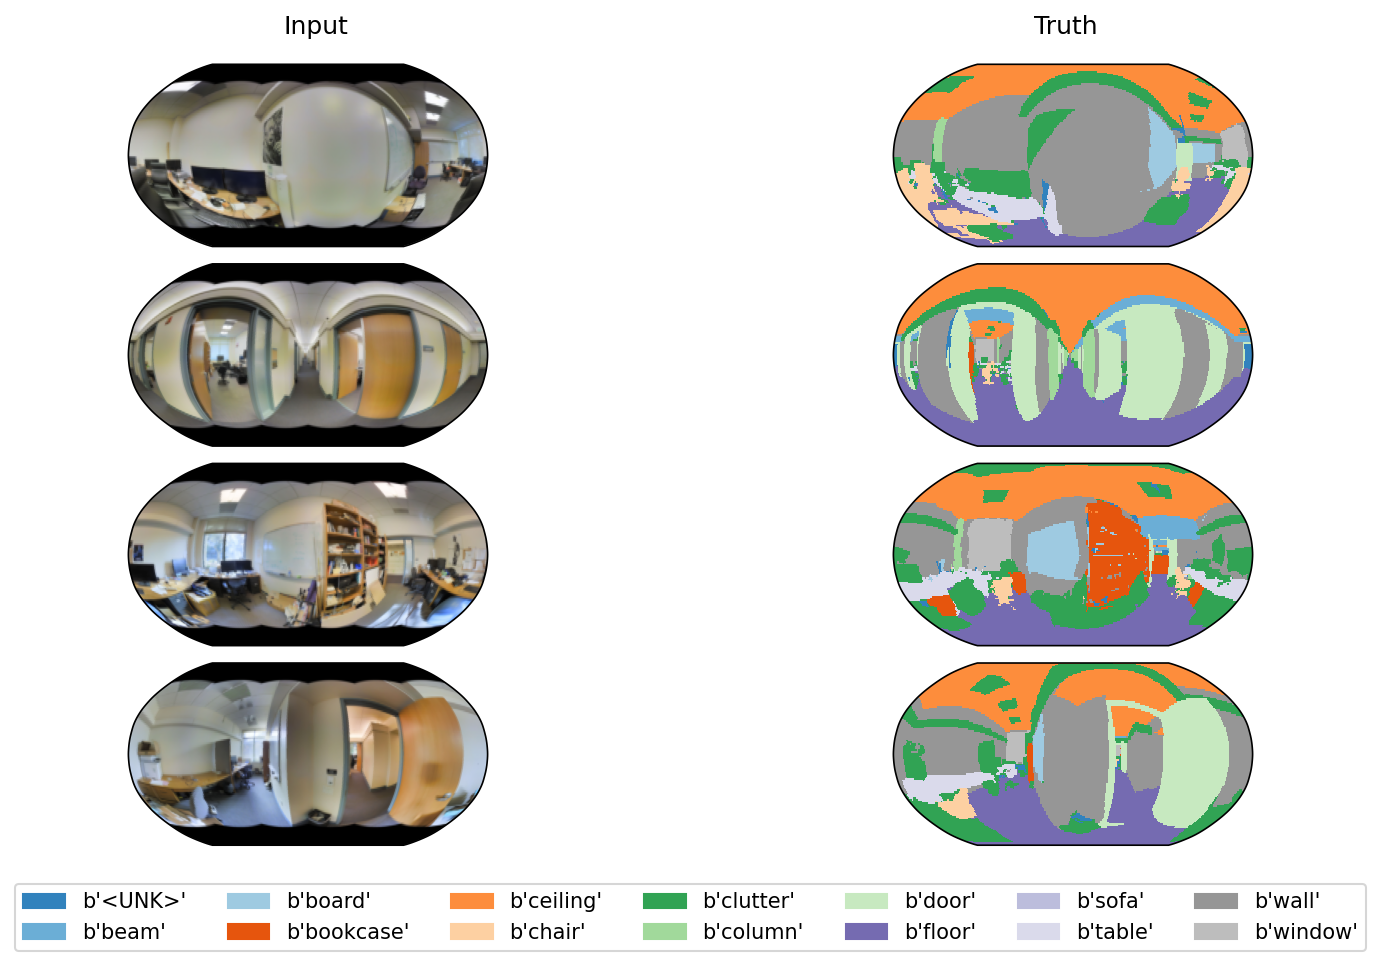

In [5]:
num_samples = 4

fig = plt.figure(layout="constrained", figsize=(10, 6.5), dpi=150)

# thin strips at the top (column headers) and bottom (legend) so every image
# row keeps the same size -- putting titles inside the top-row subfigures would
# shrink only the first row.
header_fig, grid_fig, legend_fig = fig.subfigures(
    3, 1, height_ratios=[0.25, num_samples, 0.6]
)

# 2 columns (Input, Truth)
subfigs = grid_fig.subfigures(num_samples, 2, wspace=0.04)

cmap = mpl.colormaps["tab20c"]

for isample in range(num_samples):

    inp = np.transpose(h5file["rgb"][isample, ...], (1, 2, 0))
    tar = h5file["semantic"][isample, ...]

    # do the plotting
    imshow_sphere(inp, fig=subfigs[isample, 0])
    plot_sphere(tar / num_classes, fig=subfigs[isample, 1], cmap=cmap, vmin=0.0, vmax=1.0)

# build the legend handles once
legend_list = [
    mpatches.Patch(color=cmap(cidx / num_classes), label=cname)
    for cidx, cname in enumerate(class_labels)
]

# column headers in their own top strip (aligned with the two columns)
for j, label in enumerate(["Input", "Truth"]):
    header_fig.text((j + 0.5) / 2, 0.5, label, va="center", ha="center", fontsize="large")

# legend in its own bottom strip
legend_fig.legend(handles=legend_list, loc="center", ncol=7)

### Class distribution

The class histogram reveals a strong imbalance — walls, floors, and ceilings
dominate, while objects like boards and bookcases are rare. This imbalance
is important to account for when training segmentation models:

In [6]:
class_labels = [cl.decode("utf-8") for cl in class_labels]

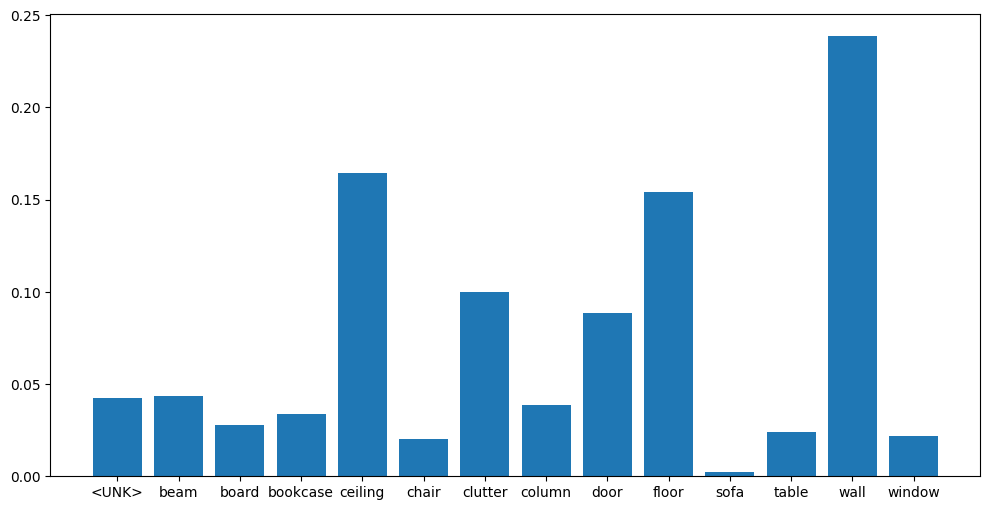

In [7]:
fig = plt.figure(figsize=(12,6))
plt.bar(class_labels, class_histogram)
plt.show()

## Depth estimation

The dataset also provides per-pixel depth maps and validity masks.
We visualize the log-depth (to compress the dynamic range) alongside the
RGB input. Poles are masked white since the equirectangular projection
is degenerate there:

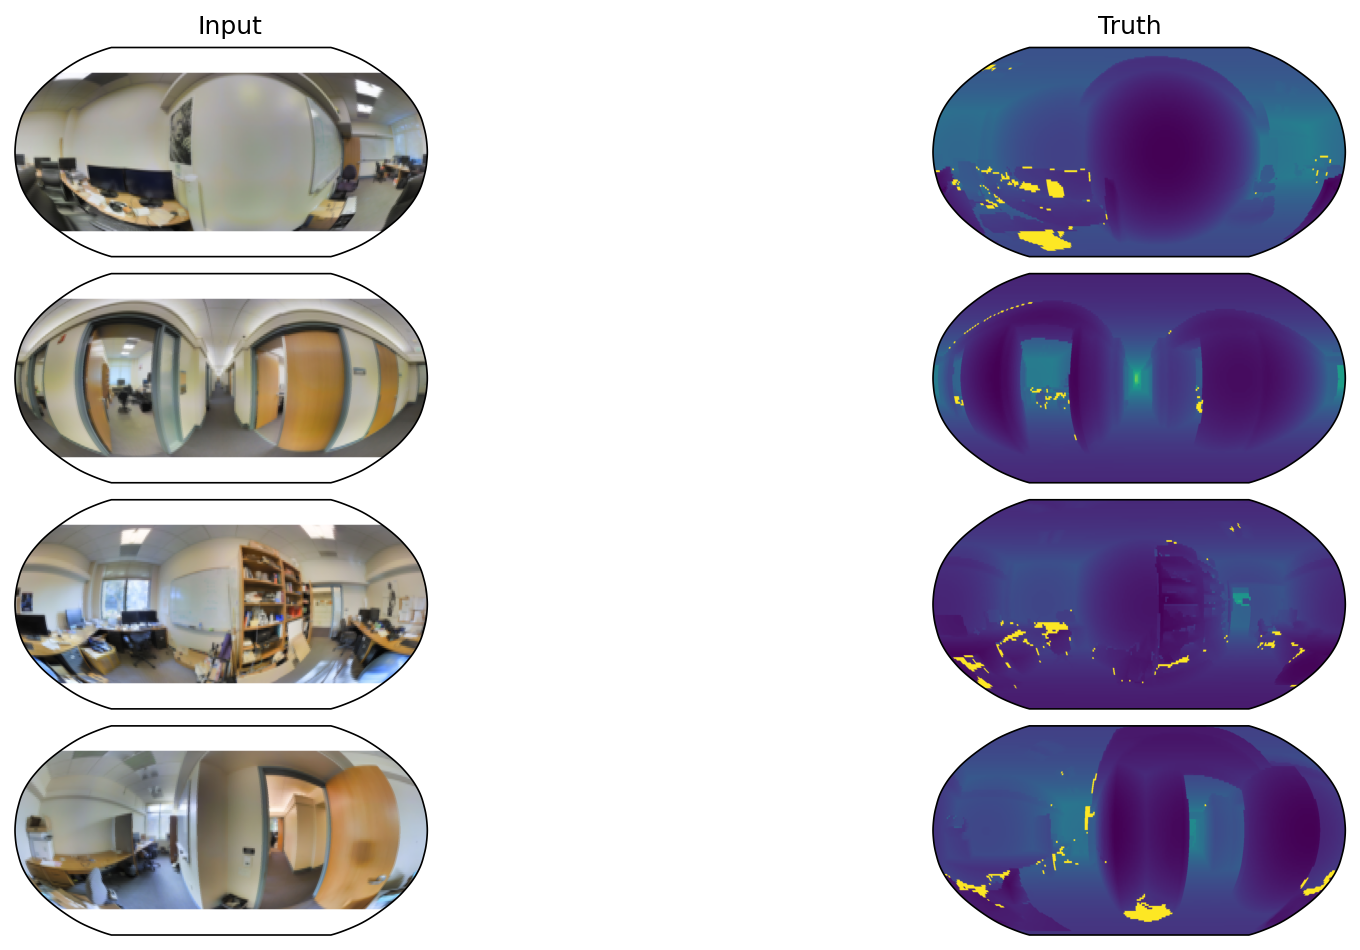

In [8]:
num_samples = 4

fig = plt.figure(figsize=(12, 6), dpi=150, layout="constrained")
subfigs = fig.subfigures(num_samples, 2, wspace=0.04)

cmap = mpl.colormaps["tab20c"]

for isample in range(num_samples):

    inp = np.transpose(h5file["rgb"][isample, ...], (1,2,0))
    inp[0:20, :, :] = [1, 1, 1]
    inp[-20:, :, :] = [1, 1, 1]
    tar = h5file["depth"][isample, ...]
    # depth_mask is not stored in the dataset -- invalid pixels are encoded as the
    # maximum depth value, so derive the mask on the fly (cf. Depth._mask_invalid)
    mask = np.where(tar == tar.max(), 0, 1)

    # do the plotting
    imshow_sphere(inp, fig=subfigs[isample, 0])
    imshow_sphere(np.log(tar)*mask, fig =subfigs[isample, 1], cmap="viridis")

# Add column labels
column_labels = ["Input", "Truth"]
for j, label in enumerate(column_labels):
    fig.text((j + 0.5) / 2, 1.03, label, va="top", ha="center", fontsize="large")



### Depth statistics

We compute the distribution of log-depth values across the dataset.
The normalization statistics (mean, std) stored in the HDF5 file can be
used for standardizing the depth targets during training:

Max:  0.99998474
Min:  0.0016479492
Mean log depth: 0.01472963752582171
Std log depth: 0.009298770923114956


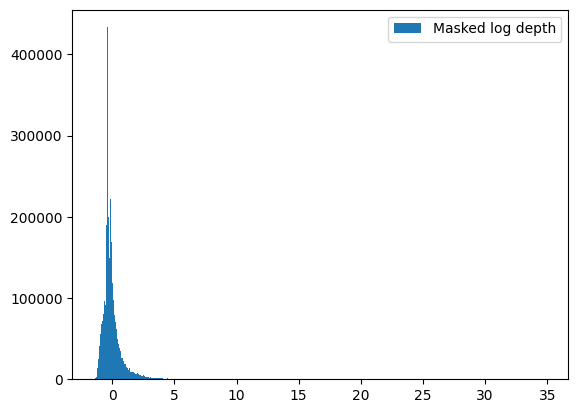

In [9]:
min_depth = h5file["min_depth"][...]
max_depth = h5file["max_depth"][...]
mean_depth = h5file["mean_depth"][...]
std_depth = h5file["std_depth"][...]

depth = h5file["depth"][...]
# invalid pixels are encoded as the maximum depth value (no stored mask)
mask_depth = np.where(depth == depth.max(), 0, 1)

print("Max: ", depth.max())
print("Min: ", depth.min())
m = np.log(1 + depth) * mask_depth
m = m[m!=0]
print(f"Mean log depth: {np.nanmean(m)}")
print(f"Std log depth: {np.nanstd(m)}")
m = (m - np.mean(m)) / np.std(m)

counts, bin_edges, _ = plt.hist(m.flatten(), 1000, label="Masked log depth")
plt.legend()

### RGB statistics

Per-channel RGB statistics for input normalization:

In [10]:
min_rgb = h5file["min_rgb"][...]
max_rgb = h5file["max_rgb"][...]
mean_rgb = h5file["mean_rgb"][...]
std_rgb = h5file["std_rgb"][...]

print(f"Min rgb: {min_rgb}")
print(f"Max rgb: {max_rgb}")
print(f"Mean rgb: {mean_rgb}")
print(f"Std rgb: {std_rgb}")

Min rgb: [0. 0. 0.]
Max rgb: [0.84705883 0.8        0.81960785]
Mean rgb: [0.49967027 0.48454845 0.4377965 ]
Std rgb: [0.38496047 0.38471302 0.38496676]
